# Heat Diffusion PDE

## Prerequisites

Add the Congrads package to the current Colab notebook environment and install it.

In [ ]:
!pip install "congrads[examples]"

Import the necessary functions and classes.

In [2]:
import random

import numpy as np
import torch
from matplotlib import pyplot as plt
from torch import Tensor
from torch.nn import Module
from torch.nn.modules.loss import _Loss
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset, TensorDataset, random_split
from IPython.display import clear_output

from congrads.callbacks.base import Callback, CallbackManager
from congrads.constraints.base import Constraint
from congrads.constraints.registry import ImplicationConstraint, PDEConstraint, ScalarConstraint
from congrads.core.congradscore import CongradsCore
from congrads.core.constraint_engine import ConstraintEngine
from congrads.descriptor import Descriptor
from congrads.metrics import MetricManager
from congrads.networks.registry import MLPNetwork
from congrads.utils.utility import DictDatasetWrapper, Seeder, lhs

Define utility functions for the dataset and plotting.

In [3]:
def to_numpy(tensor: Tensor) -> np.ndarray:
    return tensor.detach().cpu().numpy()


class Loader:
    """Samples training, validation and test data for the 1D heat equation.

    Initial condition (IC), boundary condition (BC) and interior
    (collocation) points are sampled separately and tagged through a
    `context` column, so that the loss and constraints can later treat
    them differently.
    """

    def __init__(self, L: float, kappa: float, lambda_tau: float, base_seed: int = 42):
        self.L = L
        self.kappa = kappa
        self.lambda_tau = lambda_tau

        self.seeder = Seeder(base_seed=base_seed)
        self.seeder.set_reproducible()

        # spatial domain
        self.x_min, self.x_max = 0, self.L
        # diffusive time scale
        self.tau = self.L**2 / self.kappa
        # time domain
        self.t_min, self.t_max = 0, self.lambda_tau * self.tau

        # limits and ranges
        self.x_range = self.x_max - self.x_min
        self.t_range = self.t_max - self.t_min
        self.X_min = [self.x_min, self.t_min]
        self.X_max = [self.x_max, self.t_max]
        self.X_range = [self.x_range, self.t_range]

    def load(
        self,
        N_IC=128,
        N_BC=128,
        N_col=1024,
        N_test=1024,
        batch_size_train=64,
        batch_size_valid=512,
        batch_size_test=1024,
    ):
        X_IC, u_IC = self._sample_IC(N=N_IC)
        X_BC, u_BC = self._sample_BC(N=N_BC)
        X_col, u_col = self._sample_domain(N=N_col)
        X_test, u_test = self._sample_domain(N=N_test)

        ctx_col = torch.full((len(X_col), 1), 0.0)  # collocation points
        ctx_IC = torch.full((len(X_IC), 1), 1.0)  # initial condition points
        ctx_BC = torch.full((len(X_BC), 1), 2.0)  # boundary condition points

        X_train = torch.cat([X_col, X_IC, X_BC], dim=0)
        u_train = torch.cat([u_col, u_IC, u_BC], dim=0)
        ctx_train = torch.cat([ctx_col, ctx_IC, ctx_BC], dim=0)

        trainval_dataset = TensorDataset(X_train, u_train, ctx_train)
        test_dataset = TensorDataset(X_test, u_test, torch.full((len(X_test), 1), 0.0))

        # Split the trainval data into training and validation sets
        generator = torch.Generator().manual_seed(self.seeder.roll_seed())
        train_dataset, valid_dataset = random_split(
            trainval_dataset, [0.8, 0.2], generator=generator
        )

        # Convert datasets to Congrads compatible dict-based ones
        train_dataset = DictDatasetWrapper(train_dataset, ["input", "target", "context"])
        valid_dataset = DictDatasetWrapper(valid_dataset, ["input", "target", "context"])
        test_dataset = DictDatasetWrapper(test_dataset, ["input", "target", "context"])

        # Datasets to loaders
        train_loader = self._dataset_to_loader(
            train_dataset, batch_size=batch_size_train, shuffle=True
        )
        valid_loader = self._dataset_to_loader(
            valid_dataset, batch_size=batch_size_valid, shuffle=False
        )
        test_loader = self._dataset_to_loader(
            test_dataset, batch_size=batch_size_test, shuffle=False
        )

        return train_loader, valid_loader, test_loader

    def _dataset_to_loader(
        self, dataset: Dataset, batch_size: int, shuffle: bool, num_workers: int = 4
    ) -> DataLoader:
        def seed_worker(worker_id):
            worker_seed = self.seeder.roll_seed()
            np.random.seed(worker_seed)
            random.seed(worker_seed)

        generator = torch.Generator().manual_seed(self.seeder.roll_seed())
        return DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=shuffle,
            num_workers=num_workers,
            worker_init_fn=seed_worker,
            generator=generator,
            persistent_workers=True,
        )

    def regular_grid(self, N=128):
        """Provides coordinates and solution on a regular grid, tagged as
        collocation (0), initial condition (1) or boundary condition (2)."""
        # Coordinate ticks
        x = np.linspace(self.x_min, self.x_max, N)
        t = np.linspace(self.t_min, self.t_max, N)
        # Meshgrid
        xx, tt = np.meshgrid(x, t)
        X_np = np.vstack((xx.flatten(), tt.flatten())).T
        X = self._array2tensor(X_np, exp_dim=False)
        # solution
        u = self._array2tensor(self._analytical_solution(X), exp_dim=False)

        # ---- classification ----
        tol = 1e-12

        x_vals = X_np[:, 0]
        t_vals = X_np[:, 1]

        is_left = np.isclose(x_vals, self.x_min, atol=tol)
        is_right = np.isclose(x_vals, self.x_max, atol=tol)
        is_initial = np.isclose(t_vals, self.t_min, atol=tol)

        identifiers = np.zeros(X_np.shape[0])

        # initial condition first
        identifiers[is_initial] = 1

        # spatial boundary (but not IC)
        boundary = (is_left | is_right) & (~is_initial)
        identifiers[boundary] = 2

        identifiers = torch.as_tensor(identifiers).unsqueeze(1).float()

        return X, u, identifiers

    def _array2tensor(self, array, exp_dim=True):
        """Auxilary function to convert numpy-array to tensor, expands
        dimensions if necessary."""
        if exp_dim:
            array = torch.unsqueeze(array, dim=1)

        return torch.as_tensor(array, dtype=torch.float32)

    def _analytical_solution(self, X):
        """Returns analytical solution for the diffusion equation."""
        x, t = X[:, 0], X[:, 1]

        u = torch.sin(torch.pi * x / self.L) * torch.exp(-(torch.pi**2) * t / self.tau)
        return self._array2tensor(u, exp_dim=True)

    def _sample_IC(self, N=128):
        """Provides random samples of IC with N data points.
        IC: u = sin(pi * x / L)"""
        # IC coordinates (t=0)
        x_ticks = np.random.rand(N) * self.x_range
        X_IC = self._array2tensor([[x, 0] for x in x_ticks], exp_dim=False)
        # IC temperature
        u_IC = self._array2tensor([[np.sin(np.pi * x / self.L)] for x in x_ticks], exp_dim=False)

        return X_IC, u_IC

    def _sample_BC(self, N=128):
        """Provides random samples of BC with N data points at each
        boundary (top and bottom). BC: u = 0"""
        # top boundary coordinates (x=x_max)
        t_ticks = np.random.rand(N) * self.t_range
        X_top = [[self.x_max, t] for t in t_ticks]
        # bottom boundary coordinates (x=x_min)
        t_ticks = np.random.rand(N) * self.t_range
        X_bottom = [[self.x_min, t] for t in t_ticks]
        # add both boundaries and provide BC temperature
        X_BC = self._array2tensor(X_top + X_bottom, exp_dim=False)
        u_BC = self._array2tensor([[0]] * X_BC.shape[0], exp_dim=False)

        return X_BC, u_BC

    def _sample_domain(self, N=1024):
        """LHS sampling of coordinates inside the function domain."""
        # coordinates
        X = self._array2tensor(self.X_min + self.X_range * lhs(2, N), exp_dim=False)
        # solution
        u = self._array2tensor(self._analytical_solution(X), exp_dim=False)

        return X, u


def plot_pde_solution(network: Module, loader: Loader, device: torch.device, N=101):
    """Evaluate the network on a regular grid and compare it to the
    analytical solution."""
    X, u_true, c = loader.regular_grid(N=N)
    dataset = DictDatasetWrapper(TensorDataset(X, u_true, c), ["input", "target", "context"])
    data_loader = loader._dataset_to_loader(dataset, batch_size=len(dataset), shuffle=False)

    network.eval()
    batch = next(iter(data_loader))
    batch = {key: batch[key].to(device) for key in batch.keys()}
    batch = network(batch)
    batch = {key: batch[key].cpu() for key in batch.keys()}

    X, u_true, u_pred = to_numpy(batch["input"]), to_numpy(batch["target"]), to_numpy(batch["output"])

    # Reshape to 2D grid
    x = np.unique(X[:, 0])
    t = np.unique(X[:, 1])

    u_true_grid = u_true.reshape(N, N).T
    u_pred_grid = u_pred.reshape(N, N).T
    u_diff_grid = np.abs(u_pred_grid - u_true_grid)

    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=True, constrained_layout=True)

    # --- True solution ---
    im0 = axes[0].imshow(
        u_true_grid, extent=[t.min(), t.max(), x.min(), x.max()], origin="lower", aspect="auto"
    )
    axes[0].set_title("True Solution")
    axes[0].set_xlabel("t")
    axes[0].set_ylabel("x")

    # --- Predicted solution ---
    im1 = axes[1].imshow(
        u_pred_grid, extent=[t.min(), t.max(), x.min(), x.max()], origin="lower", aspect="auto"
    )
    axes[1].set_title("Predicted Solution")
    axes[1].set_xlabel("t")

    cbar1 = fig.colorbar(im1, ax=axes[1])
    cbar1.set_label("u")

    # --- Difference ---
    im2 = axes[2].imshow(
        u_diff_grid, extent=[t.min(), t.max(), x.min(), x.max()], origin="lower", aspect="auto"
    )
    axes[2].set_title("Difference")
    axes[2].set_xlabel("t")

    cbar2 = fig.colorbar(im2, ax=axes[2])
    cbar2.set_label("|û - u|")

    fig.suptitle("True vs Predicted Solutions")

    return fig

Before starting with the general training procedure, we fix the randomizer seeds and get the device on which we are training our model:



*   We have a built-in [Seeder class](https://congrads.readthedocs.io/en/latest/api.html#congrads.utils.utility.Seeder) that will pseudo-randomly fix the seeds of random number generators, Numpy and PyTorch.
*   If there is a GPU available, use it. Otherwise fall back to CPU.



In [4]:
# Set seed for reproducibility
seeder = Seeder(base_seed=42)
seeder.set_reproducible()

# CUDA for PyTorch
use_cuda = torch.cuda.is_available()
device = torch.device("cuda:0" if use_cuda else "cpu")

## Problem description

In this example, the goal is to demonstrate how the Congrads toolbox can be used to build a **physics-informed neural network (PINN)** that solves a partial differential equation (PDE), rather than fitting a regression to a set of ground truth targets.

We consider the 1D heat (diffusion) equation on a rod of length $L$:

$$\frac{\partial u}{\partial t} = \kappa\,\frac{\partial^2 u}{\partial x^2}, \qquad x \in [0, L],\ t \in [0,\, \lambda_\tau \tau]$$

with diffusive time scale $\tau = L^2 / \kappa$, subject to:

* Initial condition: $u(x, 0) = \sin(\pi x / L)$
* Boundary conditions: $u(0, t) = u(L, t) = 0$

This particular setup has a known analytical solution, which we use both to generate training data and to evaluate the trained network:

$$u(x, t) = \sin(\pi x / L)\, e^{-\pi^2 t / \tau}$$

Instead of only supervising the network on sampled input/output pairs, we additionally constrain it so that its predictions respect the PDE itself. This is done by using the network's own input gradients (via automatic differentiation) to compute PDE residuals, and enforcing these residuals to be (close to) zero everywhere in the domain through dedicated [`PDEConstraint`](https://congrads.readthedocs.io/en/latest/api.html#congrads.constraints.registry.PDEConstraint) constraints.

## Dataset

For PINNs, the "dataset" consists of a mix of point clouds sampled from different parts of the problem domain:

*   **Initial condition (IC) points**: sampled at $t=0$, labeled with the known initial temperature $\sin(\pi x / L)$.
*   **Boundary condition (BC) points**: sampled at $x=0$ and $x=L$, labeled with temperature $0$.
*   **Collocation points**: sampled inside the domain using [Latin Hypercube Sampling](https://congrads.readthedocs.io/en/latest/api.html#congrads.utils.utility.lhs) (`lhs`). These points carry the analytical solution as well, but are mainly used to enforce that the PDE residual vanishes throughout the domain.

We define a small custom `Loader` (defined above) around these sampling routines, and tag every sample with a `context` value (0 = collocation, 1 = IC, 2 = BC) so that the loss and constraints can later distinguish between them.

In [5]:
# Physical and geometric parameters of the problem
L = 1.0
kappa = 1.0
lambda_tau = 1.0

# Load and preprocess data
loader = Loader(L=L, kappa=kappa, lambda_tau=lambda_tau, base_seed=seeder.roll_seed())
train_loader, valid_loader, test_loader = loader.load()

## Network

Physics-informed constraints require access to the derivatives of the network output with respect to its inputs. We therefore build a custom network on top of the built-in [MLPNetwork](https://congrads.readthedocs.io/en/latest/api.html#congrads.networks.registry.MLPNetwork) that:

*   Enables gradient tracking on the input coordinates $(x, t)$.
*   Exposes the last hidden representation as a separate `final_layer` output, so constraints can compute gradients with respect to it.
*   Uses [`torch.autograd.grad`](https://docs.pytorch.org/docs/stable/generated/torch.autograd.grad.html) with `create_graph=True` to compute $\partial u/\partial x$, $\partial u/\partial t$ and $\partial^2 u/\partial x^2$, and combines them into three PDE residuals:

*   `col_residual` $= \kappa\, \partial^2 u/\partial x^2 - \partial u/\partial t$: the PDE residual itself, which should vanish everywhere in the domain.
*   `ic_residual` $= \partial u/\partial t + \kappa\, \pi^2/L^2 \sin(\pi x/L)$: enforces that the network's time-derivative at $t=0$ matches the analytical initial rate of cooling.
*   `bc_residual` $= \kappa\, \partial^2 u/\partial x^2$: enforces that curvature vanishes at the spatial boundaries, consistent with $u$ being pinned to $0$ there for all $t$.

Note that this requires setting `network_uses_grad=True` on the `CongradsCore` further down, so that gradients stay enabled during evaluation as well.

In [6]:
class CustomNetwork(MLPNetwork):
    """Adjusts MLPNetwork to calculate several residuals using gradients."""

    def __init__(
        self,
        L,
        kappa,
        n_inputs,
        n_outputs,
        n_hidden_layers=4,
        hidden_dim=50,
        activation=torch.nn.Tanh(),
    ):
        self.L = L
        self.kappa = kappa

        # Initialize MLPNetwork without final layer
        super().__init__(
            n_inputs=n_inputs,
            n_outputs=hidden_dim,
            n_hidden_layers=n_hidden_layers - 1,
            hidden_dim=hidden_dim,
            activation=activation,
        )

        # Add final layer manually
        self.final_linear = torch.nn.Linear(hidden_dim, n_outputs)
        self.final_activation = torch.nn.Tanh()

    def forward(self, data):
        # Enable gradient tracking for input
        data["input"].requires_grad_()

        # Get base network output without final layer
        data = super().forward(data)

        # Reconstruct output while keeping track of before last layer
        data["final_layer"] = self.final_activation(data["output"]).requires_grad_()
        data["output"] = self.final_linear(data["final_layer"])

        # Extract input and output tensors
        input = data["input"]
        output = data["output"]

        # Extract spatial and temporal coordinates
        x, t = input[:, 0].unsqueeze(1), input[:, 1].unsqueeze(1)

        # Compute 1st order gradients
        du_dX = torch.autograd.grad(output.sum(), input, retain_graph=True, create_graph=True)[0]
        du_dx = du_dX[:, 0].unsqueeze(1)
        du_dt = du_dX[:, 1].unsqueeze(1)

        # Compute 2nd order gradient
        d2u_dx2 = torch.autograd.grad(du_dx.sum(), input, retain_graph=True, create_graph=True)[0]
        d2u_dx2 = d2u_dx2[:, 0].unsqueeze(1)

        # Compute residuals
        bc_residual = self.kappa * d2u_dx2
        ic_residual = (
            du_dt + self.kappa * torch.sin(torch.pi * x / self.L) * torch.pi**2 / self.L**2
        )
        col_residual = self.kappa * d2u_dx2 - du_dt

        # Add residuals to data dict
        data["bc_residual"] = bc_residual.abs()
        data["ic_residual"] = ic_residual.abs()
        data["col_residual"] = col_residual.abs()

        return data

In [7]:
# Instantiate network and push to correct device
network = CustomNetwork(L=L, kappa=kappa, n_inputs=2, n_outputs=1, n_hidden_layers=3, hidden_dim=100)
network = network.to(device)

## Descriptor

The descriptor is a bit more elaborate for this example, since the network exposes several intermediate quantities besides its final `output`.

We register each of these as a separate **layer**:

*   `input` and `output` for the coordinates and the predicted temperature.
*   `bc_residual`, `ic_residual` and `col_residual` for the three PDE residuals computed inside the network.
*   `final_layer`, the last hidden representation, which the residual layers depend on.

The residual layers are marked with `affects_loss=False` (they must not be supervised directly) and `gradients_from="final_layer"`, so that the `PDEConstraint` can differentiate them with respect to `final_layer` to obtain a correction direction.

Finally, we add tags to select specific columns from these layers: `x` and `t` from `input`, and one tag per residual layer.

In [8]:
# Instantiate descriptor
descriptor = Descriptor()
descriptor.add_layer("input", constant=True)
descriptor.add_layer("output")
descriptor.add_layer("bc_residual", affects_loss=False, gradients_from="final_layer")
descriptor.add_layer("ic_residual", affects_loss=False, gradients_from="final_layer")
descriptor.add_layer("col_residual", affects_loss=False, gradients_from="final_layer")
descriptor.add_layer("final_layer")

descriptor.add_tag("x", "input", 0)
descriptor.add_tag("t", "input", 1)
descriptor.add_tag("bc_residual", "bc_residual", 0)
descriptor.add_tag("ic_residual", "ic_residual", 0)
descriptor.add_tag("col_residual", "col_residual", 0)
descriptor.add_tag("final_layer", "final_layer", 0)

## Constraints

With the descriptor in place, we can define the constraints that guide the network towards a solution of the PDE.

We use [`PDEConstraint`](https://congrads.readthedocs.io/en/latest/api.html#congrads.constraints.registry.PDEConstraint) to enforce that a residual stays below a small threshold, and wrap it in an [`ImplicationConstraint`](https://congrads.readthedocs.io/en/latest/api.html#congrads.constraints.registry.ImplicationConstraint) whenever the residual should only apply to a specific subset of the domain (selected through a `ScalarConstraint` on $x$ or $t$):

*   If $x \le 0$ or $x \ge 1$ (at the spatial boundary), then `bc_residual` $< 0.001$.
*   If $t \le 0$ (at the initial condition), then `ic_residual` $< 0.001$.
*   Everywhere in the domain, `col_residual` $< 0.001$ &mdash; this is the actual PDE residual constraint.

In [9]:
# Assign descriptor to constraint base
Constraint.descriptor = descriptor

# Assign device to constraint base
Constraint.device = device

# Define constraints
constraints = [
    ImplicationConstraint(
        head=ScalarConstraint("x", "<=", 0),
        body=PDEConstraint(
            layer_base="final_layer",
            tag_residual="bc_residual",
            comparator="<",
            scalar=0.001,
            rescale_factor=2.0,
        ),
    ),
    ImplicationConstraint(
        head=ScalarConstraint("x", ">=", 1),
        body=PDEConstraint(
            layer_base="final_layer",
            tag_residual="bc_residual",
            comparator="<",
            scalar=0.001,
            rescale_factor=2.0,
        ),
    ),
    ImplicationConstraint(
        head=ScalarConstraint("t", "<=", 0),
        body=PDEConstraint(
            layer_base="final_layer",
            tag_residual="ic_residual",
            comparator="<",
            scalar=0.001,
            rescale_factor=2.0,
        ),
    ),
    PDEConstraint(
        layer_base="final_layer",
        tag_residual="col_residual",
        comparator="<",
        scalar=0.001,
        rescale_factor=1.5,
    ),
]

## Loss and optimizer

Besides the PDE constraints, we still supervise the network directly on the initial and boundary condition samples, since those have known ground-truth values ($\sin(\pi x / L)$ and $0$ respectively). Collocation points do not contribute to this loss.

We implement this with a small custom `BoundaryMSE` loss that masks out every sample whose `context` equals $0$ (collocation points), and averages the mean squared error over the remaining (IC/BC) samples only.

We stick to the Adam optimizer for this example.

In [10]:
class BoundaryMSE(_Loss):
    """Computes MSE loss only for boundary samples (initial and boundary)."""

    def forward(self, output: Tensor, target: Tensor, data: dict[str, Tensor]) -> Tensor:
        # Mask for boundary samples
        is_boundary = (data["context"][:, 0] != 0).float().unsqueeze(1)

        # Per-sample MSE
        mse_per_sample = torch.mean(torch.square(output - target), dim=1, keepdim=True)

        # Avoid division by zero if no samples match
        denominator = is_boundary.sum().clamp_min(1.0)
        boundary_loss = torch.sum(mse_per_sample * is_boundary) / denominator

        return boundary_loss

In [11]:
# Instantiate loss and optimizer
criterion = BoundaryMSE()
optimizer = Adam(network.parameters(), lr=1e-4)

## Metric manager

To allow keeping track of constraint satisfaction rates for each individual constraint, as well as the losses and possibly other metrics, we set up a [MetricManager](https://congrads.readthedocs.io/en/latest/api.html#module-congrads.metrics) system.

In [12]:
# Initialize metric manager
metric_manager = MetricManager()

## Callback manager

We define a plotting callback that, every 50 epochs, evaluates the network on a regular grid and compares it to the analytical solution.

Refer to the [Congrads documentation](https://congrads.readthedocs.io/en/latest/) for more info on the callback system.

In [13]:
class PlotCallback(Callback):
    def __init__(
        self, network: Module, loader: Loader, device: torch.device, max_epochs: int, plot_every=50
    ):
        super().__init__()
        self.network = network
        self.loader = loader
        self.device = device
        self.max_epochs = max_epochs
        self.plot_every = plot_every

    def on_epoch_end(self, data, ctx):
        super().on_epoch_end(data, ctx)
        epoch = data["epoch"]

        # Always redraw on the last epoch, even if it does not land on plot_every
        if epoch % self.plot_every != 0 and epoch != self.max_epochs - 1:
            return

        clear_output(wait=True)

        print(f"Epoch: {epoch}")
        plot_pde_solution(self.network, self.loader, self.device)
        plt.show()
        plt.close()

In [14]:
# Number of training epochs
max_epochs = 5000

callback_manager = CallbackManager()
callback_manager.add(PlotCallback(network, loader, device, max_epochs=max_epochs))

<CallbackManager callbacks=['PlotCallback'] ctx_keys=[]>

## Constraint engine

Collocation points have no ground-truth target and therefore always contribute zero to the `BoundaryMSE` loss, which means their loss gradient is zero. To keep the constraint-guided update balanced for these points as well, we override the `ConstraintEngine` so that, for every batch, collocation samples borrow the (maximum) loss-gradient magnitude computed on the IC/BC samples in that same batch, instead of using their own (zero) gradient.

In [15]:
class CustomConstraintEngine(ConstraintEngine):
    """Overrides loss gradients for collocation samples based on boundary sample gradients."""

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.grad_buffer = None

    def _override_loss_gradients(self, norm_loss_grad, loss, data):
        # Mask to select only boundary samples (initial and boundary conditions)
        is_boundary = data["context"][:, 0] != 0

        if is_boundary.any():
            output_gradients = norm_loss_grad["final_layer"]

            # Mask gradients to boundary only and compute the maximum gradient
            masked_gradients = output_gradients[is_boundary]
            aggregated_gradient = masked_gradients.amax()

            # Set gradients of collocation samples to the maximum gradient of boundary samples
            norm_loss_grad["final_layer"][~is_boundary] = aggregated_gradient

            # Keep track of previous norm_loss_grad
            self.grad_buffer = aggregated_gradient

        else:
            # If no boundary samples in batch, fall back to aggregated gradient of previous batch
            norm_loss_grad["final_layer"][~is_boundary] = self.grad_buffer

        return norm_loss_grad

## Core

The [CongradsCore](https://congrads.readthedocs.io/en/latest/api.html#congrads.core.congradscore.CongradsCore) is the brain of the toolbox. It orchestrates the functionality of all previously created objects, integrating descriptors, constraints, and optimization strategies to perform constraint-guided gradient descent.

For this example we pass our `CustomConstraintEngine` through `constraint_engine_cls`, and set `network_uses_grad=True` so that gradients remain enabled during validation and testing as well (required for the residual computations in `CustomNetwork`).

In [16]:
# Instantiate core
core = CongradsCore(
    descriptor=descriptor,
    constraints=constraints,
    dataloader_train=train_loader,
    dataloader_valid=valid_loader,
    dataloader_test=test_loader,
    network=network,
    criterion=criterion,
    optimizer=optimizer,
    metric_manager=metric_manager,
    callback_manager=callback_manager,
    device=device,
    enforce_all=True,
    network_uses_grad=True,
    constraint_engine_cls=CustomConstraintEngine,
)

Finally, we can start training by running the `core.fit(...)` function. This function allows setting the maximum epochs and callback functions and will start the training process.

Epoch: 750


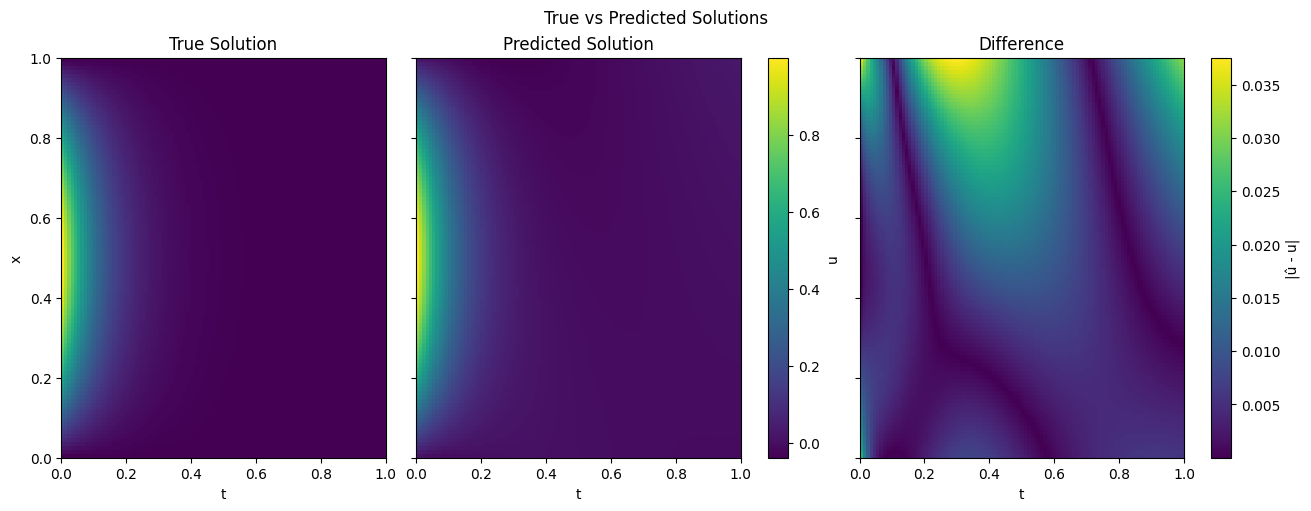

Epoch:  15%|█▌        | 774/5000 [07:39<41:46,  1.69it/s]  


KeyboardInterrupt: 

In [17]:
# Start training
core.fit(max_epochs=max_epochs)